In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,r2_score,accuracy_score,confusion_matrix,classification_report
import joblib

In [2]:
# Loading dataset
df =pd.read_excel(r"C:\Users\Admin\Desktop\Shrawani\Projects\EV\EV intelligence system\data\EV_data.xlsx")

In [3]:
# first 5 rows from dataset
df.head()

,Time,Speed,Crank,Ignition,A_Batt_Current,A_Batt_Voltage,B_Batt_Current,B_Batt_Voltage,A_Batt_soc,B_Batt_soc,...,MCU_temp,Motor_temp,Accel_pedal,MCU_torque,MCU_Speed,MCU_Current_DC,MCU_Voltage_DC,MCU_AC_Voltage,MCU_AC_Current,Odometer
0,115.8,-3,1,1,-3.0,688.6,-3.5,688.6,100.0,100.0,...,35,31,4,-150.5,-94,3.5,687.2,21.5,56.7,10010.7
1,115.9,-3,1,1,-3.0,688.4,-3.5,688.4,100.0,100.0,...,35,31,4,-139.8,-94,3.1,688.0,20.7,53.9,10010.7
2,116.2,-3,1,1,-2.5,688.6,-3.5,688.6,100.0,100.0,...,35,31,4,-114.8,-97,2.5,688.7,20.1,46.2,10010.7
3,116.4,-3,1,1,-2.5,688.6,-3.0,688.6,100.0,100.0,...,35,31,3,-100.6,-99,2.3,687.3,20.3,41.4,10010.7
4,116.5,-3,1,1,-3.0,688.6,-3.0,688.6,100.0,100.0,...,35,31,0,-64.5,-93,1.8,687.9,17.8,39.2,10010.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167908 entries, 0 to 167907
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Time                     167908 non-null  float64
 1   Speed                    167908 non-null  int64  
 2   Crank                    167908 non-null  int64  
 3   Ignition                 167908 non-null  int64  
 4   A_Batt_Current           167908 non-null  float64
 5   A_Batt_Voltage           167908 non-null  float64
 6   B_Batt_Current           167908 non-null  float64
 7   B_Batt_Voltage           167908 non-null  float64
 8   A_Batt_soc               167908 non-null  float64
 9   B_Batt_soc               167908 non-null  float64
 10  B_Batt_Charge_energy     167908 non-null  float64
 11  B_Batt_Discharge_energy  167908 non-null  float64
 12  B_Batt_Regen_energy      167908 non-null  float64
 13  A_Batt_Charge_energy     167908 non-null  float64
 14  A_Ba

In [5]:
# Check missing values
df.isnull().sum()

Time                       0
Speed                      0
Crank                      0
Ignition                   0
A_Batt_Current             0
A_Batt_Voltage             0
B_Batt_Current             0
B_Batt_Voltage             0
A_Batt_soc                 0
B_Batt_soc                 0
B_Batt_Charge_energy       0
B_Batt_Discharge_energy    0
B_Batt_Regen_energy        0
A_Batt_Charge_energy       0
A_Batt_Discharge energy    0
A_Batt_Regen_energy        0
Torque                     0
MCU_temp                   0
Motor_temp                 0
Accel_pedal                0
MCU_torque                 0
MCU_Speed                  0
MCU_Current_DC             0
MCU_Voltage_DC             0
MCU_AC_Voltage             0
MCU_AC_Current             0
Odometer                   0
dtype: int64

In [6]:
# check duplicae values
df.duplicated().sum()

np.int64(0)

In [7]:
#Let's remove unnessesary rows by considering valid conditions

In [8]:
df=df[(df["Ignition"]==1) & (df["Crank"]==1) & (df["Speed"]>0)].reset_index(drop=True)

In [9]:
df.shape

(145058, 27)

## Feature Engineering

In [10]:
# Time

In [11]:
df["dt"]=df["Time"].diff().fillna(0.1)

### Power

In [12]:
df['Power_A'] = df['A_Batt_Voltage'] * df['A_Batt_Current']
df['Power_B'] = df['B_Batt_Voltage'] * df['B_Batt_Current']
df['Total_Power'] = df['Power_A'] + df['Power_B']

### Driving Dynamics

In [13]:
window=600
df['Acceleration'] = (df['Speed'].diff().rolling(window).sum()/df["dt"]).fillna(0.0)
df['Jerk'] = (df['Acceleration'].diff().rolling(window).sum()/df["dt"]).fillna(0.0)

### Torque

In [14]:
df['Torque_Load'] = df['Torque'] * df['Speed']
df['Torque_Ratio'] = df['Torque'] / (df['Speed']+1)

### Thermal Features

In [15]:
df['Temp_diff'] = df['Motor_temp'] - df['MCU_temp']

### SOC change

In [16]:
df["Total_SOC"]=df["A_Batt_soc"]+df["B_Batt_soc"]

In [17]:
df['SOC_drop'] = df['Total_SOC'].diff().fillna(0)

# Target Variable

### for Energy Prediction (Regression)

In [18]:
df["Total_Discharge_energy"]=df["A_Batt_Discharge energy"]+df["B_Batt_Discharge_energy"]

### for Driving Style Classification (Classificaion)

In [19]:
# Threshold caluculation

In [90]:
low_torque = df["Torque_Load"].quantile(0.25)
high_torque = df["Torque_Load"].quantile(0.75)

low_speed = df["Speed"].quantile(0.25)
high_speed = df["Speed"].quantile(0.75)

In [21]:
# print("low torque:",low_torque)
# print("high torque:",high_torque)
# print("low speed:",low_speed)
# print("high speed:",high_speed)

In [22]:
# torque_low=df["Torque"].quantile(0.33)
# torque_high=df["Torque"].quantile(0.66)

In [23]:
# print("low torque:",torque_low)
# print("high torque:",torque_high)

In [24]:
# df["Speed"].mean()

In [91]:
def classify(row):
    if row["Torque_Load"] <= low_torque and row["Speed"] <= low_speed:
        return "Eco"
    elif row["Torque_Load"] >= high_torque and row["Speed"] >= high_speed:
        return "Aggressive"
    else:
        return "Normal"

df["Driving_style"] = df.apply(classify, axis=1)

In [26]:
# print(df["Driving_style"].value_counts())

# Model 1: Energy Prediction (Regression)

In [30]:
features = [
    'Speed','Torque','MCU_torque','Accel_pedal',
    'MCU_Current_DC','MCU_Voltage_DC',
    'Motor_temp','MCU_temp',
    'Torque_Load','Acceleration','SOC_drop'
]

In [31]:
X=df[features]

In [32]:
y=df["Total_Discharge_energy"]

In [33]:
# Train-test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

### Model building using Random Forest algorithm

In [35]:
reg_model = RandomForestRegressor(n_estimators=100)


In [36]:
reg_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
# model Evaluation

In [38]:
y_test_pred=reg_model.predict(X_test)

In [39]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

MAE: 0.7638532073574953
R2: 0.997460688050173


# Model 2: Driving Style Classification

In [92]:
features = [
    "Motor_temp",
    "MCU_temp",
    "MCU_Voltage_DC",
    "MCU_AC_Current",
    "Speed"
]

In [93]:
X_cls = df[features]
y_cls = df['Driving_style']

In [94]:
y_cls.value_counts()

Driving_style
Normal        122606
Eco            16116
Aggressive      6336
Name: count, dtype: int64

In [43]:
# train-test-split

In [95]:
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X_cls, y_cls, test_size=0.2,random_state=42)

### Model building using Random Forest algorithm

In [96]:
clf = RandomForestClassifier(class_weight="balanced",
    max_depth=8,
    min_samples_split=10,
    random_state=42)

In [97]:
clf.fit(X_cls_train, y_cls_train)

,n_estimators,100
,criterion,'gini'
,max_depth,8
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
y_pred_cls = clf.predict(X_cls_test)
print(classification_report(y_cls_test, y_pred_cls))

              precision    recall  f1-score   support

  Aggressive       0.70      0.99      0.82      1282
         Eco       0.85      0.99      0.91      3187
      Normal       1.00      0.96      0.98     24543

    accuracy                           0.96     29012
   macro avg       0.85      0.98      0.90     29012
weighted avg       0.97      0.96      0.96     29012



In [48]:
# Let's plot confusion matrix

<Axes: >

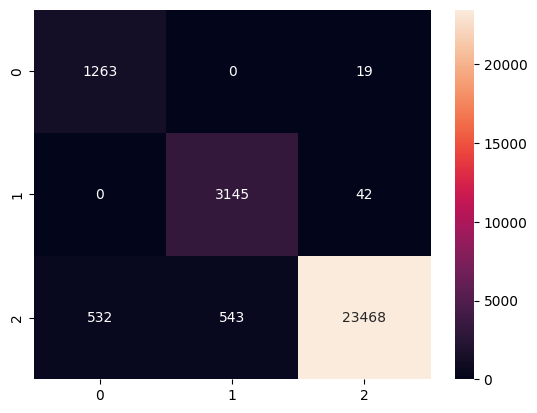

In [100]:
cm = confusion_matrix(y_cls_test, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d')

# Explainability using SHAP

In [50]:
import shap

C:\Users\Admin\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [75]:
X_sample = X_cls_test.sample(1000, random_state=42)

In [76]:
explainer = shap.TreeExplainer(clf)

In [77]:
shap_values = explainer.shap_values(X_sample)

In [54]:
# For Aggressive class

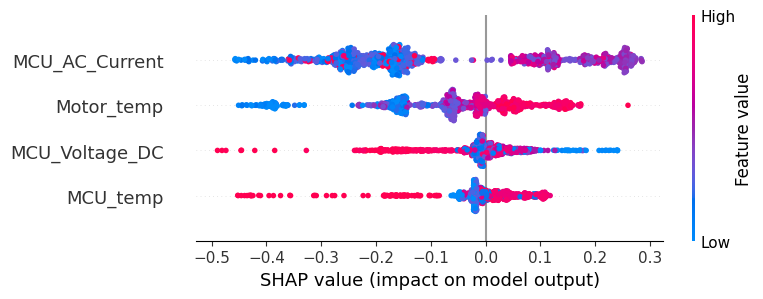

In [78]:
shap.summary_plot(shap_values[:, :, 0], X_sample)

In [56]:
# For Eco class

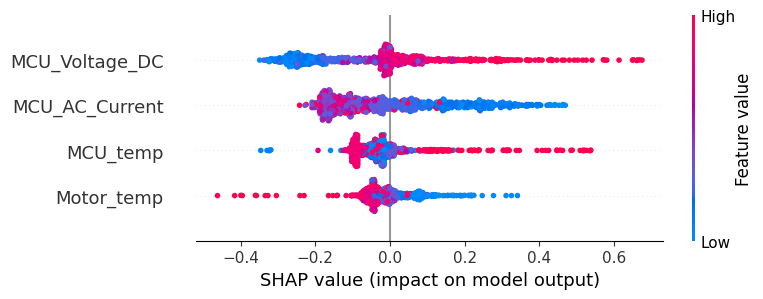

In [79]:
shap.summary_plot(shap_values[:, :, 1], X_sample)

In [58]:
# For Normal class

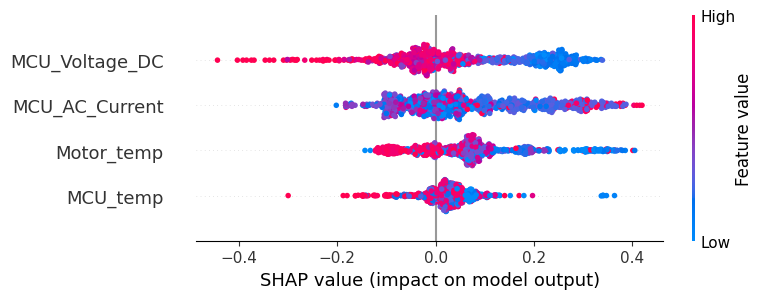

In [80]:
shap.summary_plot(shap_values[:, :, 2], X_sample)

In [101]:
joblib.dump(clf, "model.pkl")

['model.pkl']

In [102]:
joblib.dump(features, "features.pkl")

['features.pkl']

In [103]:
features

['Motor_temp', 'MCU_temp', 'MCU_Voltage_DC', 'MCU_AC_Current', 'Speed']

In [104]:
print(y_cls.value_counts())


Driving_style
Normal        122606
Eco            16116
Aggressive      6336
Name: count, dtype: int64


In [108]:
model = joblib.load("model.pkl")

test = pd.DataFrame([{
    'Motor_temp': 20,
    "MCU_temp": 40,
    "MCU_Voltage_DC": 300,
    'MCU_AC_Current': 120,
    "Speed": 20
}])

print("Prediction:", model.predict(test))
print("Features:", model.feature_names_in_)

Prediction: ['Normal']
Features: ['Motor_temp' 'MCU_temp' 'MCU_Voltage_DC' 'MCU_AC_Current' 'Speed']


In [109]:
df.describe()

,Time,Speed,Crank,Ignition,A_Batt_Current,A_Batt_Voltage,B_Batt_Current,B_Batt_Voltage,A_Batt_soc,B_Batt_soc,...,Total_Power,Acceleration,Jerk,Torque_Load,Torque_Ratio,Temp_diff,Total_SOC,SOC_drop,Total_Discharge_energy,score
count,145058.000000,145058.000000,145058.0,145058.0,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000,...,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000,145058.000000
mean,8499.224659,43.454039,1.0,1.0,-20.643918,676.854674,-21.281708,676.854674,68.424001,67.955478,...,-28328.591475,2.011979,1.985910,7264.228652,5.444885,4.705311,136.379479,-0.000826,12631.978612,4375.961280
std,4904.571441,10.125452,0.0,0.0,14.335483,5.110483,15.649055,5.110483,18.083478,18.600384,...,20251.564635,4.719709,46.009594,5949.430007,18.590542,2.653454,36.681375,2.299071,38.684453,3570.363261
min,137.100000,1.000000,1.0,1.0,-75.000000,661.500000,-84.000000,661.500000,39.800000,37.800000,...,-103272.400000,-0.000210,-200.000000,-29570.000000,-59.400000,-7.000000,77.600000,-61.300000,12564.500000,-17746.305691
25%,4262.625000,44.000000,1.0,1.0,-27.000000,671.900000,-28.000000,671.900000,52.900000,51.900000,...,-37201.650000,0.000000,0.000000,5004.800000,2.356863,4.000000,104.800000,0.000000,12597.100000,3021.556078
50%,8023.550000,46.000000,1.0,1.0,-20.500000,678.000000,-21.500000,678.000000,67.000000,67.200000,...,-28182.000000,0.000000,0.000000,7324.800000,3.334000,5.000000,134.200000,0.000000,12633.400000,4413.532432
75%,12860.375000,49.000000,1.0,1.0,-14.500000,681.300000,-14.500000,681.300000,84.800000,84.700000,...,-19838.750000,0.000000,0.000000,9845.750000,4.842553,6.000000,169.500000,0.000000,12666.100000,5926.665437
max,16790.700000,56.000000,1.0,1.0,62.000000,692.000000,71.500000,692.000000,100.000000,100.000000,...,91610.500000,20.000000,200.000000,28073.600000,559.200000,13.000000,200.000000,117.600000,12693.500000,16850.877302


In [110]:
df.groupby("Driving_style")[["Speed", "MCU_AC_Current"]].mean()

,Speed,MCU_AC_Current
Driving_style,,
Aggressive,50.475379,56.076121
Eco,24.253351,44.183402
Normal,45.615035,48.279722
